# Explore The Data

## Explore The Data Lable

In [ ]:
import pickle
DATA_PATH_PREFIX='/mnt/d/DataSets/WESAD'
SUBJECT_ID = 'S2'
try:
    with open(f"{DATA_PATH_PREFIX}/{SUBJECT_ID}/{SUBJECT_ID}.pkl", 'rb') as f:
        data = pickle.load(f, encoding="latin1")
        print(f"Data Load Successfully!")
except FileNotFoundError as e:
    print(f"Error:{e}")


In [12]:
print("\n--- Data Structure Overview ---")
print(f"Keys in loaded data: {data.keys()}")


--- Data Structure Overview ---
Keys in loaded data: dict_keys(['signal', 'label', 'subject'])


In [14]:
signal_data = data['signal']
print(f"Keys in signal: {signal_data.keys()}")

Keys in signal: dict_keys(['chest', 'wrist'])


In [15]:
chest_data = signal_data['chest']
print(f"Keys in chest: {chest_data.keys()}")

Keys in chest: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [21]:
# Extract ECG and labels
ecg_data = chest_data['ECG']
labels = data['label']

print(f"ECG signal shape: {ecg_data.shape}")
print(f"Labels shape: {labels.shape}")

ECG signal shape: (4255300, 1)
Labels shape: (4255300,)


In [17]:
wrist_data=signal_data['wrist']
print(f"Keys in wrist: {wrist_data.keys()}")

Keys in wrist: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [19]:
bvp_data=wrist_data['BVP']
print(f"BVP signal shape: {bvp_data.shape}")
eda_data=wrist_data['EDA']
print(f"EDA signal shape: {eda_data.shape}")

BVP signal shape: (389056, 1)
EDA signal shape: (24316, 1)


## Visualise the Data

In [22]:
ECG_SAMPLING_RATE_RESP = 700 # Hz (from WESAD documentation for RespiBAN ECG)
LABEL_SAMPLING_RATE = 700 # Hz (from WESAD documentation for labels)
HRV_INTERPOLATION_RATE = 4 # Hz (Common for HRV spectral analysis, as per RHRV example in the wavelet paper)

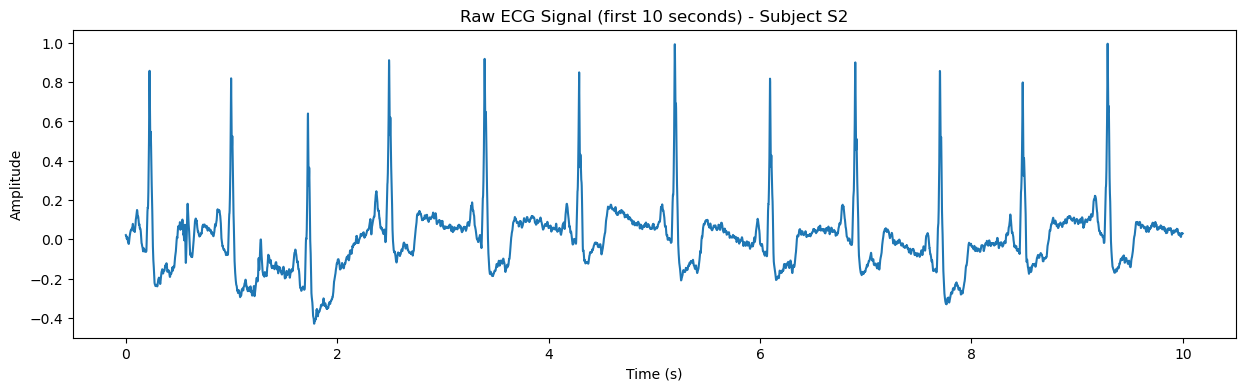

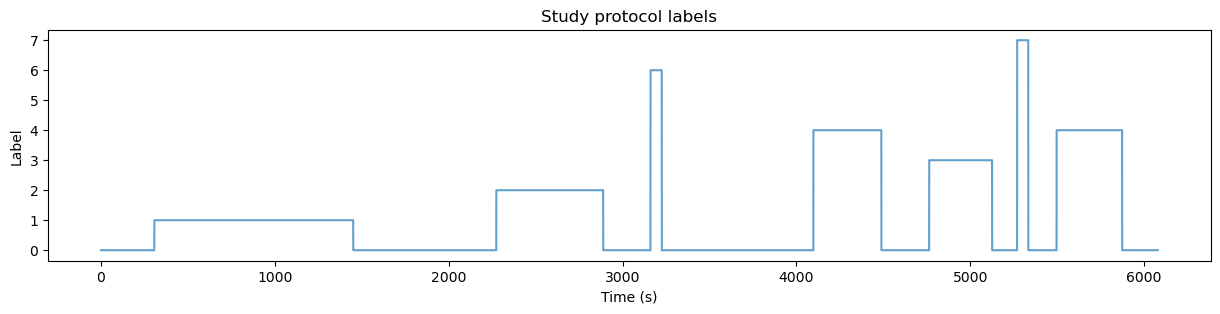

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(ecg_data[:ECG_SAMPLING_RATE_RESP*10])) / ECG_SAMPLING_RATE_RESP, 
         ecg_data[:ECG_SAMPLING_RATE_RESP*10])
plt.title(f'Raw ECG Signal (first 10 seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(labels)) / LABEL_SAMPLING_RATE, labels, alpha=0.7)
plt.title('Study protocol labels')
plt.xlabel('Time (s)')
plt.ylabel('Label')
plt.show()